# Extension to a multi-dimensional and time dependent Problem

In [1]:
import os
# Surpress unnecessary output from tensorflow package
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Change the working dorectory, for easier imports and running
os.chdir(os.path.dirname(os.path.abspath('../pyproject.toml')))

# Import necessary functions/ packages
from Utils.plot import int_3D_plot, plot_animated, simp_plot, plot_err_vs_epoch
from PINNLearning.data import gen_data, set_boundaries, time_sim, gen_rand_2D_data, set_2D_boundaries
from PINNLearning.training import learning_rate_schedule, time_loss, train
from PINNLearning.models import create_model
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import keras

# import deepxde as dde
# from deepxde.backend import tensorflow_compat_v1 ## ???


As before, we are setting some initial settings primarily for plotting.

In [2]:
# Plot settings
plt.close('all')
plt.rcParams['font.family'] = 'Ubuntu Nerd Font'
plt.rcParams['font.size'] = 10

# Dimensions of the simulation space
lower_bound = 0.0
upper_bound = 1.0

## Introduction to time dependence

We continue our exploration of the heat equation written below, but this time we will consider it as time-dependent.

$\dfrac{\partial u(x, t)}{\partial t} = \alpha \cdot \Delta u(x, t)$

To accommodate this change, the initial simplifications need to be adjusted as follows:
- The diffusion factor is set to a constant value: $\alpha = 0.1$
- The function remains one-dimensional, so we have: $\Delta u(x, t) = \frac{\partial^2 u(x, t)}{\partial^2x}$


In this context, the diffusion factor $\alpha$ is reduced to extend the "time" it takes for heat to spread throughout the system. This adjustment aids the PINN in converging, as neural networks often struggle with complex, erratic functions. This issue was also observed in the previous section of the notebook `1D & time-independent` problems. Furthermore this leads to nicer looking results.

The problem remains normalized over the range $[0,1]$, and this normalization extends to the time domain.
The Dirichlet boundary conditions are specified across the entire time range similar to before:

$u(0) = 1$ and $u(1) = 0$

Additionally, we need to introduce an initial condition for $u(x,0)$, which is defined as:

$u(x,0) = 0.5 \cdot cos(2 \cdot \pi \cdot x) + 0.5$ 

It is not strictly required for the initial solution to satisfy the boundary conditions outlined above. However, if the initial solution does not meet these conditions, both the simulated and PINN solutions may exhibit some error in relation to the problem's definition.

Due to the complexity of finding an analytical solution, a simulated approach needs to be employed again.
In this simulation, time is discretized into small intervals, and the solution is computed at each time step. This necessitates an important stability condition, which establishes a relationship between the step sizes (denoted as $\Delta$) in the $x$ and $t$ domains.
This condition is known as the Courant-Friedrichs-Lewy (CFL) condition, which states:

$r = \alpha \cdot \dfrac{\Delta t}{\Delta x^2} \overset{!}{\leq} \dfrac{1}{2}$

With the fixed discretization of the spatial domain and the specified value for $\alpha$, the CFL condition serves as the foundation for calculating the discretization of the time domain. However, since all domains are normalized, this will not impact the visual outcome of the simulation.

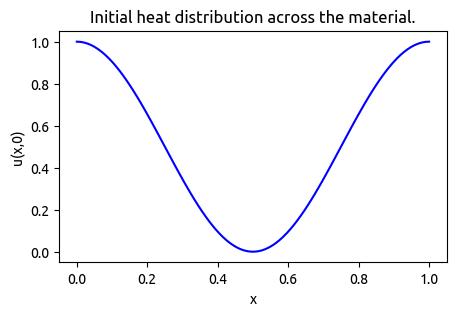

In [ ]:
# Create the data for the simulation and set the initial solution

# Discretize the x dimension
x_train = gen_data(lower_bound, upper_bound, 100)

# Set the boundary conditions
x_bc, y_bc = set_boundaries([[0.0], [1.0]], [[1.0], [0.0]])

# Create a function to generate the initial solution for t=0
def init_sol(array):
    # set the initial function with respect
    # to the boundary conditions
    # return (1 - array) + 0.1 * np.sin(2 * np.pi * array) ??????????? ----------------?? ?ßß?????
    return 0.5 * np.cos(2 * np.pi * array) + 0.5

# Set an examplery initial solution 
init_vals = init_sol(x_train)

# View the initial solution
plt = simp_plot([x_train, init_vals, 'b'],
                'Initial heat distribution across the material.',
                ylabel='u(x,0)'
                )
plt.show()

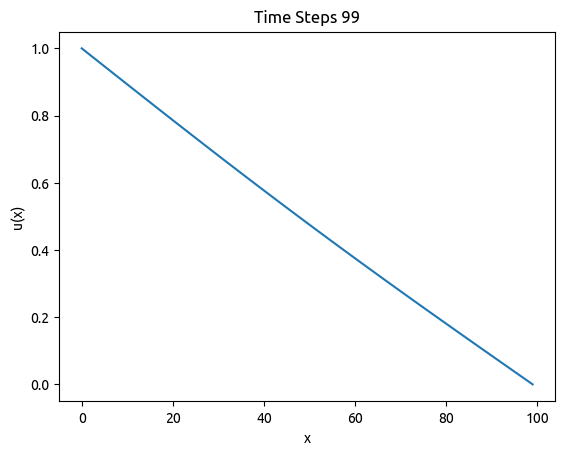

Convergence time: 2.40746s


In [13]:
# Simulate the PDE
final_res, hist, times = time_sim(x_train, y_bc, init_sol, 5)

# Plot an animation of the initial development
plot_animated(hist[:100])

# Print the time the simulation needed to fully converge
print(f"Convergence time: {times[0]:.5f}s")

In [14]:
# Create a 3D plot of the simulation

# Limit the number of displayed time steps, for easier plotting
if len(hist) > 3000:
    hist = hist[:3000]

m = len(hist)      # number of time steps
n = len(hist[0])   # number of x samples

# set up the axis
x = np.linspace(lower_bound, upper_bound, n)  # spatial dimension
z = np.linspace(lower_bound, upper_bound, m)  # temporal dimension - normalized to be in [0, 1]
X, Z = np.meshgrid(x, z)
Y = np.array(hist)  # results

plt = int_3D_plot(X, Z, Y, "Plot of the simulated spatio-temporal solution")
plt.show()

In this scenario, the following setup of the PINN differs significantly from that of the simulation.
This problem must be treated here as a two-dimensional problem in both space and time. Consequently, the training and validation data must be sampled from the $x-t~plane$, and the boundary conditions themselves must be represented as vectors of constant samples across the time domain.

With this added complexity, it is evident that the model must also increase in complexity. To accommodate this, the neural network now includes more hidden layers. Additionally, the training budget needs to be expanded; the training duration will be longer, and the learning rate must initially be increased before being gradually reduced according to the schedule. Other modifications to the framework focus primarily on adjusting the residual to be minimized and incorporating the initial solution as an additional loss term.

In this implementation, it is unlikely that the model will converge to a final solution; instead, it exhausts the training budget.
Training performance could be enhanced by further increasing the budget, the number of data points and batching the training data. Batching can be activated by providing the `train()` function with a specified batch size.
Against typicall practices, for PINNs much larger batch sizes (a typicall size would otherwise be 32) are recommended ([source](https://www.semanticscholar.org/paper/On-the-impact-of-larger-batch-size-in-the-training-Sankaran-Wang/6a89167f1764acf26e8f34871d71e65ab7a47263)).

Batching is a technique used to improve the efficiency and performance of training algorithms. Instead of processing the entire dataset at once, the data is divided into smaller subsets called batches. Each batch contains a certain power of two of randomly selected data points from the original dataset.
During training, the model is updated individually for each batch. In addition to the obvious benefits of reducing memory requirements, this approach leads to a "noisy" gradient, which can enhance exploration, and results in a higher update frequency. This may lead to faster convergence.
However, a downside is that as the number of batches increases, the gradients of the model need to be computed more frequently. This differentiation is the most time-intensive step of the learning process and can become a limiting factor in the use of this technique if sufficient parallelization is not possible.


See for more information: [Medium.com](https://medium.com/analytics-vidhya/when-and-why-are-batches-used-in-machine-learning-acda4eb00763)

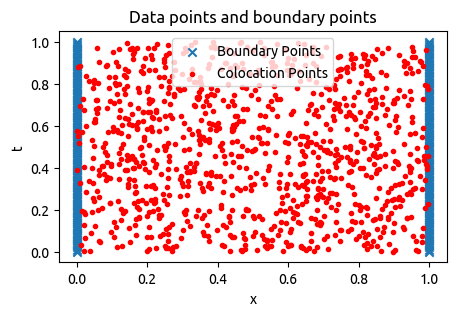

In [19]:
# Create the training and validation data set for the PINN

# Sample 500 (x, t) pairs for training
xt_train = gen_rand_2D_data(lower_bound, upper_bound, 1000)

# Generate 900 (x, t) pairs for verification
x_samps = gen_data(lower_bound, upper_bound, 30)
t_samps = gen_data(lower_bound, upper_bound, 30)
grid = tf.meshgrid(x_samps, t_samps)
grid = tf.stack(grid, axis=-1)
xt_test = tf.reshape(grid, [-1, 2])


# Extend the given boudary values to fit the 2D approach
# FYI: As the boundary conditions are set as u(<x_bound>, t), they must be provided
# as a vector of values, sampled throught the time domain. For the t_sample points,
# we are using here the x_train vector just for simplicity.
xt_bc, yt_bc = set_2D_boundaries(x_bc, y_bc, x_train)

# Plot the data points
data = [
    [xt_bc[:, 0], xt_bc[:, 1], ('marker', 'x'), 'scatter', ('label', 'Boundary Points')],
    [xt_train[:, 0], xt_train[:, 1], ('marker', '.'), ('c', 'r'), 'scatter', ('label', 'Colocation Points')]
    ]
plt = simp_plot(data, "Data points and boundary points", ylabel="t")
plt.show()


Epoch 100: Loss = 0.12392608076334
Epoch 200: Loss = 0.040608324110507965
Epoch 300: Loss = 0.014878085814416409
Epoch 400: Loss = 0.01332862488925457
Epoch 500: Loss = 0.014639068394899368
Epoch 600: Loss = 0.007624236401170492
Epoch 700: Loss = 0.007623287849128246
Epoch 800: Loss = 0.006683299783617258
Epoch 900: Loss = 0.005414307117462158
Epoch 1000: Loss = 0.015576964244246483
Epoch 1100: Loss = 0.00896430667489767
Epoch 1200: Loss = 0.006658793427050114
Epoch 1300: Loss = 0.0070068021304905415
Epoch 1400: Loss = 0.01629343256354332
Epoch 1500: Loss = 0.006858246400952339
Epoch 1600: Loss = 0.006172911264002323
Epoch 1700: Loss = 0.008065691217780113
Epoch 1800: Loss = 0.004555388819426298
Epoch 1900: Loss = 0.005913872271776199
Epoch 2000: Loss = 0.006418979726731777
Epoch 2100: Loss = 0.00871097669005394
Epoch 2200: Loss = 0.004307594150304794
Epoch 2300: Loss = 0.004605029709637165
Epoch 2400: Loss = 0.0056356219574809074
Epoch 2500: Loss = 0.006982957944273949
Epoch 2600: Los

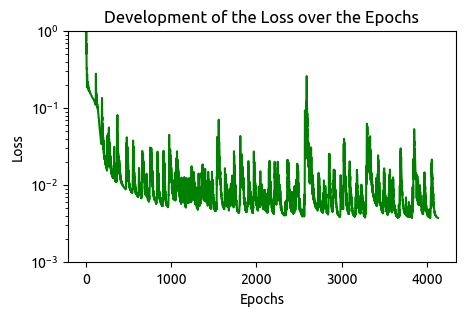

In [20]:
# Train/Test a model for a simple time dependent case

# FYI: The only modifications to make this algoritm capable of 2D are in the loss function.
# However, also the training budget (limit epochs) and the learning rate schedule were
# increased to improve performance.

# Create a model
model = create_model(5, 50)

# Create a learning rate schedule
lr_schedule = learning_rate_schedule(1e-2, 1000, 0.9)

# Closure function for to convert the time_loss for the train function
def loss(model, y_true, x_bc, y_bc):
    return time_loss(model, y_true, x_bc, y_bc, init_sol)


# Train the model for the nosy y-data if it is not already trained
try:
    # To force retraining of the model uncomment follwing line
    raise Exception

    model = keras.models.load_model('./data/time_dep.keras')
except Exception as e:
    error_time = train(model, xt_train, xt_bc, yt_bc, loss, lr_schedule, threshold=1e-8, limit=4500)
    model.save('./data/time_dep.keras')

    # Create a graph showing the loss vs the epochs
    x, y = zip(*error_time)
    data = list([x, y, 'g-', 'Model Loss'])
    plt = plot_err_vs_epoch(data, 'Development of the Loss over the Epochs', xlabel='Epochs', ylabel='Loss')
    plt.show()


# Calculate the predictions for the verification data
y_pred = model(xt_test).numpy()

# Create a 3D plot of the preditction of the PINN
X, Z = np.meshgrid(x_samps, t_samps)
Y = y_pred.reshape(30, 30)  # results

plt = int_3D_plot(X, Z, Y, "Plot of the simulated spatio-temporal solution")
plt.show()

# Two Dimensional Problems